# IPL Powerplay Score Prediction


This notebook provides a detailed walkthrough of the IPL Powerplay Score Predictor. The implementation uses a combination of feature engineering, Bayesian statistical methods for categorical encoding, and regularized linear regression to predict the score at the end of 6 overs based on the first 3 overs of an IPL match.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import os
import glob
from io import StringIO
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## Loading Match Files

For the training phase, a historical dataset is required to enable the model to learn the underlying statistical relationships between early-innings match conditions and final powerplay scores. Therefore, ball-by-ball match data from the years 2022 to 2026 (27th April) is utilized for model training.

In [2]:
data_dir = "2022-2026"
ball_files = sorted(glob.glob(os.path.join(data_dir, "*[!_info].csv")))
print(f"Total No. of Matches: {len(ball_files)}")

Total No. of Matches: 328


## Data Parsing and Cleaning

The first step involves parsing the “Ashwin-format” CSV files, which include both match metadata (info) and ball-by-ball delivery data. One minor inconsistency in the dataset was related to the RCB team name: in some seasons, "Bengaluru" was recorded as "Bangalore." This naming was standardized to improve consistency and ensure more accurate analysis. For analysis, let us consider the data corresponding to match number 1527679.

In [3]:
def _normalise_team(name):
    name = str(name)
    return name.replace("Bangalore", "Bengaluru")

def _parse_info(info_str):
    """ Parse Ashwin-format info CSV into a flat dict. """
    info = {}
    for line in info_str.strip().splitlines():
        parts = line.split(",")
        if len(parts) < 2:
            continue
        key = parts[1].strip()
        value = ",".join(parts[2:]).strip().strip('"')
        if key in info:
            if not isinstance(info[key], list):
                info[key] = [info[key]]
            info[key].append(value)
        else:
            info[key] = value
    return info

In [4]:
match_id = "1527679"
info_str = open(match_id + "_info.csv", encoding="utf-8").read()
display(_parse_info(info_str))

{'2.2.0': '',
 'balls_per_over': '6',
 'team': ['Sunrisers Hyderabad', 'Kolkata Knight Riders'],
 'gender': 'male',
 'season': '2026',
 'date': '2026/04/02',
 'event': 'Indian Premier League',
 'match_number': '6',
 'venue': 'Eden Gardens, Kolkata',
 'city': 'Kolkata',
 'toss_winner': 'Kolkata Knight Riders',
 'toss_decision': 'field',
 'player_of_match': 'Nithish Kumar Reddy',
 'umpire': ['MV Saidharshan Kumar', 'Vinod Seshan'],
 'reserve_umpire': 'Anish Sahasrabudhe',
 'tv_umpire': 'Nitin Menon',
 'match_referee': 'Shakti Singh',
 'winner': 'Sunrisers Hyderabad',
 'winner_runs': '65',
 'player': ['Sunrisers Hyderabad,TM Head',
  'Sunrisers Hyderabad,Abhishek Sharma',
  'Sunrisers Hyderabad,Ishan Kishan',
  'Sunrisers Hyderabad,H Klaasen',
  'Sunrisers Hyderabad,Aniket Verma',
  'Sunrisers Hyderabad,Nithish Kumar Reddy',
  'Sunrisers Hyderabad,S Arora',
  'Sunrisers Hyderabad,Harsh Dubey',
  'Sunrisers Hyderabad,Shivang Kumar',
  'Sunrisers Hyderabad,JD Unadkat',
  'Sunrisers Hyderaba

## Feature Engineering

Feature engineering converts the raw ball-by-ball data into a structured representation of the game state at the end of the first 3 overs. Rather than relying solely on the raw score, several derived features are created to better capture the progression and context of the innings.

- **Momentum**: Calculated as $\text{Score}_{\text{Over3}} - \text{Score}_{\text{Over0}}$. This represents the acceleration or deceleration of the scoring rate.

- **Wicket-Adjusted Score**: A counterfactual metric $S_3 \times (1 + 0.08 \times \text{Wickets})$. It penalizes the current score based on wickets lost, acknowledging that losing wickets usually leads to more conservative play in the remaining powerplay.

- **Pressure Metrics**: Features such as "dot_rate" and "extras_pressure" (based on wides and no balls) are used to measure bowling effectiveness and the discipline of the bowling side.

In addition to these dynamic features, several contextual and performance based attributes are included, such as total score at the end of 3 overs, runs scored in each individual over, wickets lost in the first 3 overs, runs scored in the most recent over to capture short-term momentum, number of boundaries, venue information, and toss-related details.

In [5]:
def _get_batting_team(info, df3):
    if "batting_team" in df3.columns and len(df3) > 0:
        return str(df3["batting_team"].iloc[0])
    teams = info.get("team", [])
    return teams[0] if teams else "Unknown"

def _get_bowling_team(info, df3):
    if "bowling_team" in df3.columns and len(df3) > 0:
        return str(df3["bowling_team"].iloc[0])
    teams = info.get("team", [])
    return teams[1] if len(teams) > 1 else "Unknown"

def _extract_features(info_str, balls_str):
    """
    Extract a feature dictionary from match-info and first-3-overs ball data.
    """
    info = _parse_info(info_str)
    df = pd.read_csv(StringIO(balls_str))

    # Numeric coercion
    for col in ["runs_off_bat", "extras", "wides", "noballs", "legbyes", "byes"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df["ball_f"] = pd.to_numeric(df["ball"], errors="coerce")
    df["total"] = df["runs_off_bat"] + df["extras"]

    # Masks
    mask3 = df["ball_f"] < 3.0
    mask_ov0 = (df["ball_f"] >= 0.0) & (df["ball_f"] < 1.0)
    mask_ov1 = (df["ball_f"] >= 1.0) & (df["ball_f"] < 2.0)
    mask_ov2 = (df["ball_f"] >= 2.0) & (df["ball_f"] < 3.0)

    df3 = df[mask3].copy()

    # Basic aggregates
    S3 = float(df3["total"].sum())
    score_ov0 = float(df[mask_ov0]["total"].sum())
    score_ov1 = float(df[mask_ov1]["total"].sum())
    score_ov2 = float(df[mask_ov2]["total"].sum())
    run_rate_3 = S3 / 3.0

    # Wickets
    wickets_3 = int(df3["wicket_type"].notna().sum())
    wicket_in_ov2 = int(df[mask_ov2]["wicket_type"].notna().sum() > 0) # Did a wicket fall in recent over?

    # Boundaries
    fours_3 = int((df3["runs_off_bat"] == 4).sum())
    sixes_3 = int((df3["runs_off_bat"] == 6).sum())
    boundaries_3 = fours_3 + sixes_3

    # Legal deliveries and rates
    legal_3 = int(((df3["wides"] == 0) & (df3["noballs"] == 0)).sum())
    legal_3 = max(legal_3, 1)
    boundary_rate = boundaries_3 / legal_3 # Boundaries per legal ball
    dot_balls = int((df3["total"] == 0).sum())
    dot_rate = dot_balls / legal_3 # Pressure metric

    # Extras
    extras_pressure = float(df3["wides"].sum() + df3["noballs"].sum())

    # Momentum
    momentum = score_ov2 - score_ov0 # +ve = Accelerating, -ve = Slowing

    # Wicket-adjusted S3
    wicket_adj_S3 = S3 * (1.0 + 0.08 * wickets_3)

    # Match context
    batting_team = _normalise_team(_get_batting_team(info, df3))
    bowling_team = _normalise_team(_get_bowling_team(info, df3))
    venue = info.get("venue", "Unknown")
    toss_winner = info.get("toss_winner", "")
    toss_decision = info.get("toss_decision", "")
    batting_won_toss = int(toss_winner == batting_team and toss_decision == "bat")

    return {
        "S3": S3, "score_ov0": score_ov0, "score_ov1": score_ov1, "score_ov2": score_ov2,
        "wickets_3": wickets_3, "wicket_in_ov2": wicket_in_ov2,
        "boundaries_3": boundaries_3, "dots_3": dot_balls,
        "extras_pressure": extras_pressure,"momentum": momentum,
        "wicket_adj_S3": wicket_adj_S3, "batting_won_toss": batting_won_toss, "venue": venue,
        "batting_team": batting_team, "bowling_team": bowling_team
    }

In [6]:
balls_str = open(match_id + ".csv", encoding="utf-8").read()
feats = _extract_features(info_str, balls_str)
display(feats)

{'S3': 91.0,
 'score_ov0': 31.0,
 'score_ov1': 24.0,
 'score_ov2': 36.0,
 'wickets_3': 1,
 'wicket_in_ov2': 0,
 'boundaries_3': 16,
 'dots_3': 10,
 'extras_pressure': 3.0,
 'momentum': 5.0,
 'wicket_adj_S3': 98.28,
 'batting_won_toss': 0,
 'venue': 'Eden Gardens, Kolkata',
 'batting_team': 'Sunrisers Hyderabad',
 'bowling_team': 'Kolkata Knight Riders'}

### Temporal Weighting

Cricket is a sport in which team form, player combinations, and scoring patterns evolve continuously over time. As a result, older matches are generally less informative for predicting present-day outcomes. For example, a match played in 2008 is significantly less relevant for estimating a score in the 2026 season than a match played in 2025.

To account for this temporal variation, an Exponential Decay weighting scheme is applied to historical matches. Each match is assigned a weight $w$ based on its age using the following decay function:

$$w = e^{-\frac{\Delta t}{L}}$$

where,

- $\Delta t$ represents the time difference in months between the historical match and the target match.

- $L$ denotes the half-life parameter, which is set to 12 months.

This ensures that the model prioritizes recent trends and team compositions over historical data. This approach gives greater importance to recent matches while gradually reducing the influence of older data. Consequently, the model becomes more responsive to current team form, modern batting strategies, rule changes, pitch conditions, and evolving player lineups.

In [7]:
def _get_match_weight(info_str, ref_date_str="2026-04-27", half_life=12.0):
    """
    Exponential decay: w = exp(−months_old / half_life).
    Matches from approx 1 year ago receive weight = 0.37; 2 years = 0.14.
    """
    date_match = re.search(r"info,date,([0-9/A-Za-z-]+)", info_str)
    if not date_match:
        return 1.0
    date_str = date_match.group(1).replace("/", "-")
    try:
        match_date = pd.to_datetime(date_str)
        ref_date = pd.to_datetime(ref_date_str)
        days_old = (ref_date - match_date).days
        months_old = max(0.0, days_old / 30.44)
        return float(np.exp(-months_old / half_life))
    except Exception:
        return 1.0

In [8]:
feats["weight"] = _get_match_weight(info_str)
print(f"Weight of the match: {feats['weight']}")

Weight of the match: 0.9338488840057463


#### Visualization of Decay Curve

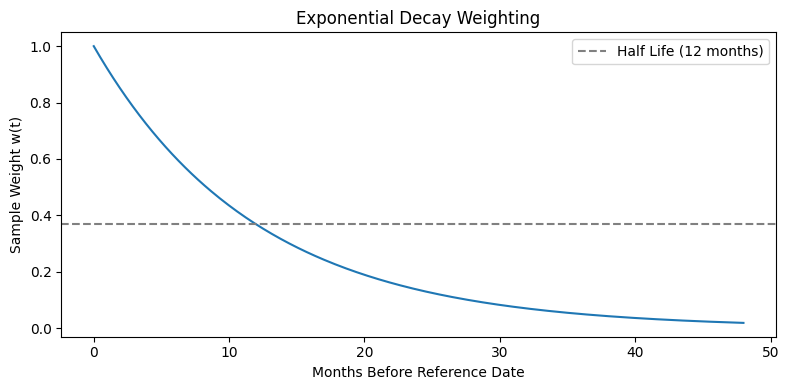

In [9]:
months = np.linspace(0, 48, 300)
weights = np.exp(-months / 12.0)

plt.figure(figsize=(8, 4))
plt.plot(months, weights)
plt.axhline(0.368, linestyle="--", color="gray", label="Half Life (12 months)")
plt.xlabel("Months Before Reference Date")
plt.ylabel("Sample Weight w(t)")
plt.title("Exponential Decay Weighting")
plt.legend()
plt.tight_layout()
plt.show()

Now, generate the feature set for all matches in the training dataset using the feature engineering steps implemented so far along with the target score.

In [10]:
def _get_powerplay_score(balls_str):
    df = pd.read_csv(StringIO(balls_str))
    for col in ["runs_off_bat", "extras"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df["ball_f"] = pd.to_numeric(df["ball"], errors="coerce")
    df["total"] = df["runs_off_bat"] + df["extras"]
    mask = (df["innings"] == 1) & (df["ball_f"] < 6.0)
    return float(df[mask]["total"].sum())

records = []
skipped = 0
for idx, bf in enumerate(ball_files):
    info_f = bf.replace(".csv", "_info.csv")
    try:
        balls_str = open(bf, encoding="utf-8").read()
        info_str = open(info_f, encoding="utf-8").read()
        df_full = pd.read_csv(StringIO(balls_str))
        df_inn1 = df_full[df_full["innings"] == 1].copy()
        df_inn1["ball_f"] = pd.to_numeric(df_inn1["ball"], errors="coerce")
        df3 = df_inn1[df_inn1["ball_f"] < 3.0]
        balls_3_str = df3.to_csv(index=False)
        feats = _extract_features(info_str, balls_3_str)
        feats["weight"] = _get_match_weight(info_str)
        feats["target"] = _get_powerplay_score(balls_str)
        records.append(feats)
    except Exception:
        skipped += 1

df_train = pd.DataFrame(records)
print(f"Training Set: {len(df_train)} Matches  (Skipped {skipped})")

Training Set: 328 Matches  (Skipped 0)


In [11]:
df_train.head()

,S3,score_ov0,score_ov1,score_ov2,wickets_3,wicket_in_ov2,boundaries_3,dots_3,extras_pressure,momentum,wicket_adj_S3,batting_won_toss,venue,batting_team,bowling_team,weight,target
0,16.0,3.0,5.0,8.0,1,0,2,13,3.0,5.0,17.28,0,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,0.016785,35.0
1,25.0,10.0,6.0,9.0,0,0,4,9,0.0,-1.0,25.00,0,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,0.016831,53.0
2,23.0,1.0,11.0,11.0,0,0,2,12,6.0,10.0,23.00,0,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bengaluru,Punjab Kings,0.016831,41.0
3,14.0,2.0,7.0,5.0,2,1,2,10,0.0,3.0,16.24,0,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,0.016877,32.0
4,13.0,1.0,5.0,7.0,0,0,2,13,2.0,6.0,13.00,0,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,0.016923,58.0


## Bayesian Smoothed Categorical Encoding

When dealing with categorical variables like venue or batting_team, simple mean encoding can lead to overfitting, especially for venues with very few matches. We use a shrinkage estimator to calculate the "effect" of a venue or team. The formula for the smoothed mean $\theta_g$ for a group $g$ is:

$$\hat{\theta_g} = \frac{n_g \ \bar{y}_g + \lambda \ \mu_{global}}{n_g + \lambda}$$

where,

- $n_g$ is the number of matches for that group.

- $\bar{y}_g$ is the sample mean for that group.

- $\mu_{global}$ is the global mean across all matches.

- $\lambda$ (prior weight) controls the strength of the shrinkage.

If $n_g$ is small, the estimate "shrinks" toward the global mean. As $n_g$ increases, the estimate relies more on the group's actual data.

This approach essentially measures the reliability of evidence:

- Small Sample Size ($n_g$ is low): The model doesn’t have enough info on the stadium yet. The estimate "shrinks" significantly toward the global mean ($\mu_{\text{global}}$).

- Large Sample Size ($n_g$ is high): The stadium has a long history. The model trusts this specific data more, and the estimate stays closer to the actual group mean ($\bar{y}_g$).

This is the posterior mean under a conjugate Normal–Normal model:

- Likelihood: The actual scores in a group follow a normal distribution centered around the true group effect: $y_i | \theta_g \sim \text{Normal}(\theta_g, \sigma^2)$.

-  Prior: Before seeing any specific stadium data, we assume the group effect itself comes from a league-wide normal distribution: $\theta_g \sim \text{Normal}(\mu_{\text{global}}, \tau^2)$.

The resulting posterior mean is exactly the weighted average shown in the equation above, where $\lambda$ represents the ratio of the variances ($\sigma^2 / \tau^2$).

In [12]:
def _smoothed_mean(df, group_col, target_col, prior_weight=8.0):
    """
    Empirical Bayes shrinkage estimator.
    For each group g with n_g observations and sample mean yb_g:
        theta_g = (n_g x yb_g + lambda x yb_global) / (n_g + lambda)
    where lambda = prior_weight controls the strength of shrinkage.
    """
    global_mean = df[target_col].mean()
    stats = {}
    for grp, grp_df in df.groupby(group_col):
        n = len(grp_df)
        grp_mean = grp_df[target_col].mean()
        smoothed = (n * grp_mean + prior_weight * global_mean) / (n + prior_weight)
        stats[grp] = smoothed
    return stats

In [13]:
grand_mean = df_train["target"].mean()
venue_stats = _smoothed_mean(df_train, "venue", "target", prior_weight=8)
team_stats = _smoothed_mean(df_train, "batting_team", "target", prior_weight=8)
bowling_stats = _smoothed_mean(df_train, "bowling_team", "target", prior_weight=8)

df_train["venue_effect"] = df_train["venue"].map(venue_stats).fillna(grand_mean)
df_train["team_effect"] = df_train["batting_team"].map(team_stats).fillna(grand_mean)
df_train["bowling_effect"] = df_train["bowling_team"].map(bowling_stats).fillna(grand_mean)

### Visualization of Shrinkage Effect


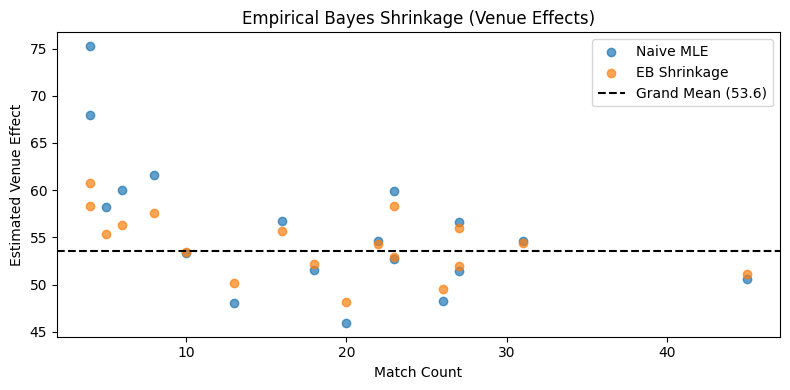

In [14]:
naive_means = df_train.groupby("venue")["target"].mean()
smoothed_means = pd.Series(venue_stats)
counts = df_train.groupby("venue")["target"].count()

plt.figure(figsize=(8, 4))
plt.scatter(counts, naive_means, label="Naive MLE", alpha=0.7)
plt.scatter(counts, smoothed_means, label="EB Shrinkage", alpha=0.7)
plt.axhline(grand_mean, color="k", linestyle="--", label=f"Grand Mean ({grand_mean:.1f})")
plt.xlabel("Match Count")
plt.ylabel("Estimated Venue Effect")
plt.title("Empirical Bayes Shrinkage (Venue Effects)")
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot will visually show low-count venues being pulled toward the grand mean!

In [15]:
## Engineered Features
feature_cols = [
    "S3", "wicket_adj_S3", "batting_won_toss",
    "score_ov0", "score_ov1", "score_ov2",
    "momentum", "wickets_3", "wicket_in_ov2",
    "boundaries_3", "dots_3", "extras_pressure",
    "venue_effect", "team_effect", "bowling_effect"
]

## Correlation Analysis

It is a statistical technique used to evaluate the strength and direction of the relationship between two variables. In the context of score prediction, it helps us identify which early-match indicators are the most reliable predictors of the final powerplay total.

The features can be filtered out based on the aspects:

- If a feature shows near zero correlation with the target, it can be considered as noise and can be discarded to simplify the model.

- If two features have a correlation near 1, they are redundant. Ridge regression handles this via regularization, but identifying it helps in understanding model behavior.

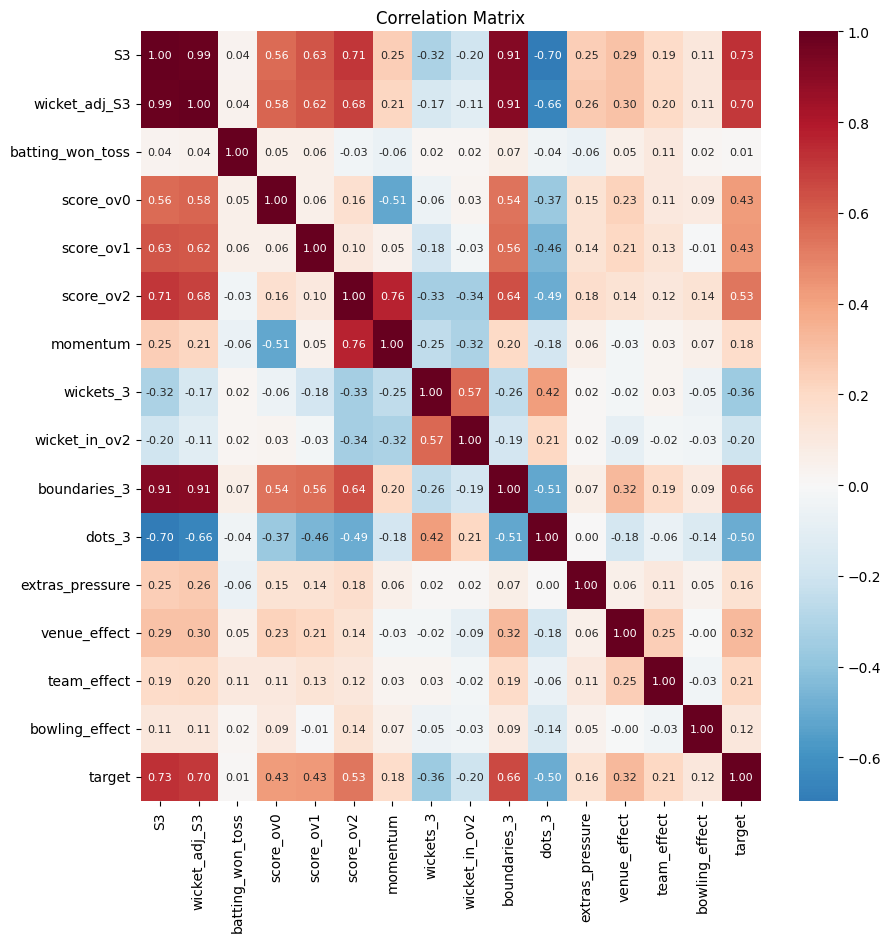

In [16]:
corr_matrix = df_train[feature_cols + ["target"]].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation Matrix")
plt.show()

We can observe that, "batting_won_toss" exhibits a very poor correlation of 0.01 with the target, hence it can be removed.

### Variance Inflation Factor (VIF)

It is a statistical measure used to detect multicollinearity in a set of multiple regression variables. To calculate VIF for a specific feature $X_j$, we perform a linear regression where $X_j$ is the target and all other features are the predictors. The VIF is then calculated using the $R^2$ value from that regression:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

- VIF = 1: No correlation between $X_j$ and other variables.

- VIF between 1 and 5: Moderate correlation; usually acceptable.

- VIF > 5 or 10: High multicollinearity; the feature is redundant and should potentially be removed.

In [17]:
vif_feats = feature_cols.copy()
vif_feats.remove("batting_won_toss")
X = df_train[vif_feats].copy()
X = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_result = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)
print(vif_result)

            Feature         VIF
1                S3         inf
3         score_ov0         inf
4         score_ov1         inf
5         score_ov2         inf
6          momentum         inf
2     wicket_adj_S3  244.342206
9      boundaries_3   11.529951
7         wickets_3    7.434839
10           dots_3    3.486283
11  extras_pressure    1.717218
8     wicket_in_ov2    1.630875
12     venue_effect    1.200857
13      team_effect    1.100967
14   bowling_effect    1.043530


Certain features have an infinite VIF value and can therefore be removed directly. In addition, "wickets_adj_S3" also exhibits a high VIF value and is removed as well. The resulting set of updated non-redundant features is listed below.

In [18]:
redundant_feats = [
    "boundaries_3", "wickets_3", "dots_3",
    "extras_pressure", "wicket_in_ov2", "venue_effect",
    "team_effect", "bowling_effect"
]

## Ridge Regression: L2-Regularized Least Squares

Ridge Regression is an extension of Linear Regression that introduces an L2 regularization term into the loss function. This regularization penalizes large coefficient values, helping to reduce the effects of multicollinearity and mitigate overfitting.

Although redundant features exhibiting high multicollinearity were removed through feature selection and VIF analysis, Ridge Regression is additionally employed to enhance the robustness, stability, and generalization performance of the model.

The objective function of Ridge Regression is given by:

$$\min \sum (y - \hat{y})^2 + \alpha \sum \beta_j^2$$

where:

- $y$ is the actual target value,

- $\hat{y}$ is the predicted target value,

- $\beta_j$ represents the model coefficients,

- $\alpha$ is the regularization parameter controlling the strength of the penalty term.

A higher value of $\alpha$ imposes a stronger penalty on the coefficients, shrinking them towards smaller values and resulting in a simpler and more stable model.

Since Ridge Regression is sensitive to feature scales, a "StandardScaler" is applied to standardize all features before training. Furthermore, "GridSearchCV" with 5-fold cross-validation is used to determine the optimal value of $\alpha$, thereby achieving an effective balance between bias and variance.


In [19]:
def train(X, y, weights, feature_names):
    param_grid = {
        "ridge__alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0],
        "ridge__max_iter": [500, 1000, 1500]
    }
    fit_params = {'ridge__sample_weight': weights}
    base_model = Pipeline([("scaler", StandardScaler()), ("ridge",  Ridge())])
    print("\nRunning GridSearchCV for Ridge Regression...")

    # K-fold validation and GridSearchCV to find the best parameters
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    gs = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1, refit=True)
    gs.fit(X, y, **fit_params)

    best = gs.best_estimator_
    best_rmse = np.sqrt(-gs.best_score_)

    # Save artefacts
    params = {
        "model": best,
        "feature_cols": feature_names,
        "venue_stats": venue_stats,
        "team_stats": team_stats,
        "bowling_stats": bowling_stats,
        "grand_mean": grand_mean,
        "cv_rmse": best_rmse,
        "best_params": gs.best_params_,
        "results": gs.cv_results_
    }
    return params

Let us compute the model parameters for both innings using both the complete feature set and the reduced feature set obtained after removing redundant features.

In [20]:
# Using redundant_feats
X = df_train[redundant_feats].values.astype(float)
y = df_train["target"].values.astype(float)
weights = df_train["weight"].values.astype(float)

red_params = train(X, y, weights, redundant_feats)

# Using feature_cols
X = df_train[feature_cols].values.astype(float)
y = df_train["target"].values.astype(float)
weights = df_train["weight"].values.astype(float)

orig_params = train(X, y, weights, feature_cols)


Running GridSearchCV for Ridge Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Running GridSearchCV for Ridge Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


### Model Evaluation

Using the optimal parameters obtained from training, the model is evaluated on unseen test data to assess its performance in terms of RMSE. For this evaluation, match data from 28th April 2026 to 13th May 2026 is used as the test dataset.

In [21]:
def predict(match_data, ball_by_ball_data, params):
    """
    Predict total first-innings powerplay (6-over) runs.
    """
    feats = _extract_features(match_data, ball_by_ball_data)

    # Resolve categorical features to their Bayesian-smoothed numeric effects
    grand_mean = params["grand_mean"]
    feats["venue_effect"] = params["venue_stats"].get(feats["venue"], grand_mean)
    feats["team_effect"] = params["team_stats"].get(feats["batting_team"], grand_mean)
    feats["bowling_effect"] = params["bowling_stats"].get(feats["bowling_team"], grand_mean)

    x = np.array([feats[c] for c in params["feature_cols"]], dtype=float).reshape(1, -1)
    pred = float(params["model"].predict(x)[0])

    # Clip to sensible IPL powerplay range
    return float(np.clip(pred, 5.0, 130.0))

def _get_match_title(info_str):
    info = _parse_info(info_str)
    teams = info.get("team", [])
    if isinstance(teams, str):
        teams = [teams]
    short_names = {
        'Chennai Super Kings': 'SRH',
        'Mumbai Indians': 'MI',
        'Royal Challengers Bengaluru': 'RCB',
        'Lucknow Super Giants': 'LSG',
        'Rajasthan Royals': 'RR',
        'Kolkata Knight Riders': 'KKR',
        'Punjab Kings': 'PBKS',
        'Gujarat Titans': 'GT',
        'Delhi Capitals': 'DC',
        'Sunrisers Hyderabad': 'SRH'
    }
    return f"{short_names[teams[0]]} vs {short_names[teams[1]]}"

def evaluate_test_matches(test_dir, params):
    ball_files = sorted(glob.glob(os.path.join(test_dir, "*[!_info].csv")))
    results = []

    for bf in ball_files:
        base_name = os.path.basename(bf)
        match_id = base_name.replace(".csv", "")
        info_file = os.path.join(test_dir, f"{match_id}_info.csv")

        try:
            with open(bf, "r", encoding="utf-8") as f:
                full_balls_str = f.read()
            with open(info_file, "r", encoding="utf-8") as f:
                info_str = f.read()

            df = pd.read_csv(StringIO(full_balls_str))
            df["ball_f"] = pd.to_numeric(df["ball"], errors="coerce")
            df_inn1 = df[df["innings"] == 1]
            df3 = df_inn1[df_inn1["ball_f"] < 3.0]
            balls_3_str = df3.to_csv(index=False)
            pred = predict(info_str, balls_3_str, params)
            actual_s6 = _get_powerplay_score(full_balls_str)
            
            results.append({
                "match": _get_match_title(info_str),
                "actual_s6": actual_s6,
                "pred_s6": pred
            })

        except Exception:
            continue

    return pd.DataFrame(results)

def plot_match_predictions(results_df):
    matches = results_df["match"]
    actual = results_df["actual_s6"]
    predicted = results_df["pred_s6"]
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    x = np.arange(len(matches))

    plt.figure(figsize=(10, 4))
    plt.plot(x, actual, 'o-', label="Actual Powerplay Score", linewidth=1)
    plt.plot(x, predicted, 's-', label="Predicted Powerplay Score", linewidth=1)
    plt.xticks(x, matches, rotation=90, fontsize=8)
    plt.ylabel("Powerplay Score")
    plt.xlabel("Match")
    plt.title(f"Actual vs Predicted IPL Powerplay Scores (RMSE: {rmse:.3f})")
    plt.legend()
    plt.grid(alpha=0.6)
    plt.tight_layout()
    plt.show()

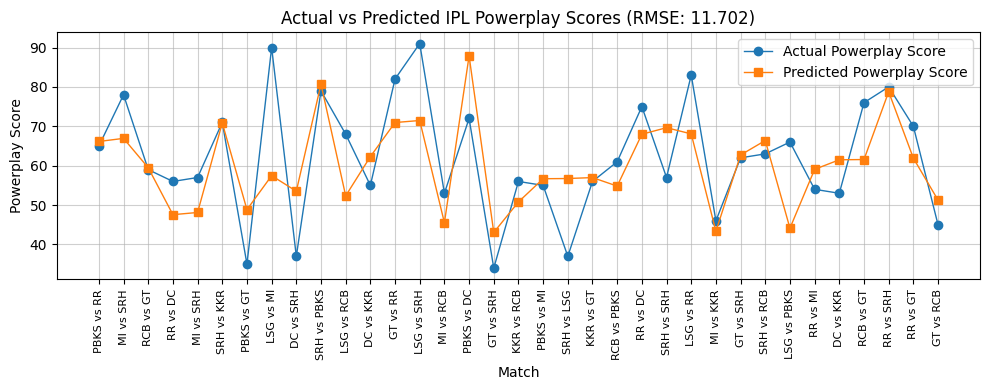

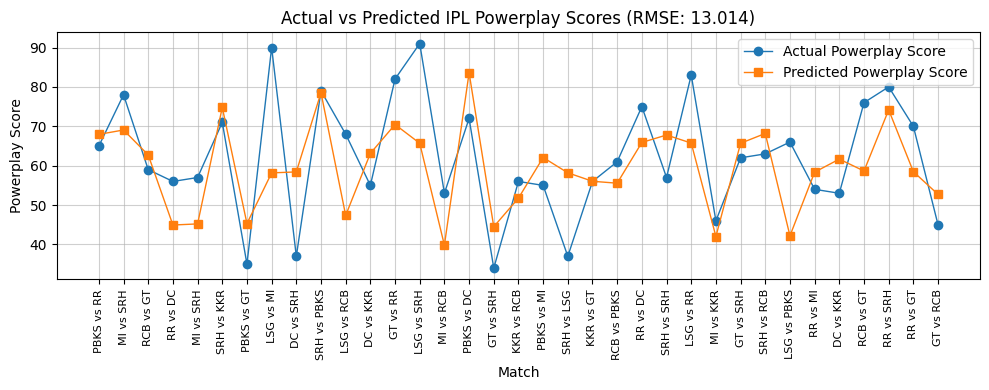

In [22]:
test_dir = "2026_test_data"
orig = evaluate_test_matches(test_dir, orig_params)
red = evaluate_test_matches(test_dir, red_params)

plot_match_predictions(orig)
plot_match_predictions(red)

It can be observed that the original feature set yields the lowest RMSE; therefore, it is selected for the final model.